In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
train_df = pd.read_csv('train.csv')

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
train_df.loc[0]

,0
PassengerId,1
Survived,0
Pclass,3
Name,"Braund, Mr. Owen Harris"
Sex,male
Age,22.0
SibSp,1
Parch,0
Ticket,A/5 21171
Fare,7.25


In [5]:
train_df.drop(['Name', 'Ticket', 'PassengerId', 'Cabin'], axis=1, inplace=True)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [6]:
X = train_df.drop('Survived', axis=1, inplace=False)
y = train_df['Survived']

print(f'Input features shape: {X.shape}')
print(f'Labels shape: {y.shape}')

Input features shape: (891, 7)
Labels shape: (891,)


In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

Text(0, 0.5, 'Number of Passengers')

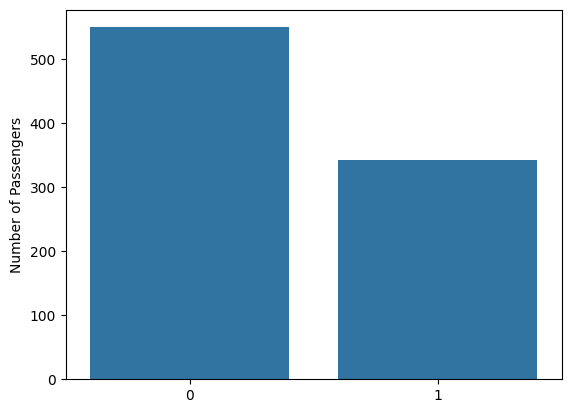

In [8]:
sns.barplot(x = y.unique(), y = y.value_counts())
plt.ylabel('Number of Passengers')

   Pclass  Sex  Age  SibSp  Parch  Fare  Embarked
0     891  891  714    891    891   891       889


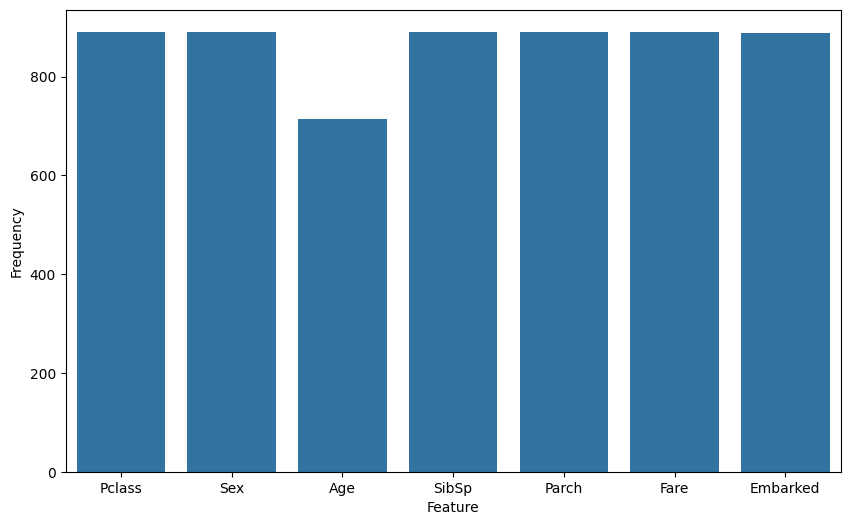

In [9]:
frequencies = X.count()

freq_df = pd.DataFrame([frequencies], columns=X.columns)
print(freq_df.head())

plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y = frequencies)
plt.ylabel('Frequency')
plt.xlabel('Feature')
plt.show()

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('cat_imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder())
])

In [11]:
from sklearn.compose import ColumnTransformer

num_attribs = ['Age', 'SibSp', 'Parch', 'Fare']
cat_attribs = ['Pclass', 'Sex', 'Embarked']

full_pipeline = ColumnTransformer([("num", num_pipeline, num_attribs),
                                   ("cat", cat_pipeline, cat_attribs)])
X = full_pipeline.fit_transform(X)
X.shape

(891, 12)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers as L

In [14]:
#Step 1
model = Sequential(name='titanic_model')

#Step 2
model.add(L.InputLayer(input_shape=(12,))) # necessary to use model.summary()

#Step 3
model.add(L.Dense(512, activation='relu'))
model.add(L.Dense(1024, activation='relu'))
model.add(L.Dropout(0.4)) #prevents overfitting by setting 40% of nuerons to 0
model.add(L.Dense(512, activation='relu'))
model.add(L.Dropout(0.4))
model.add(L.Dense(128, activation='relu'))
model.add(L.Dense(64, activation='relu'))
model.add(L.Dense(64, activation='relu'))
model.add(L.Dense(1, activation='sigmoid')) # output layer, use sigmoid for binary

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "titanic_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,134,913 (4.33 MB)

 Trainable params: 1,134,913 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#Step 4
model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(0.0001), metrics=['accuracy'])

In [16]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_accuracy')>0.83):
            print("\nReached 83% accuracy so cancelling training!")
            self.model.stop_training = True


#Step 6
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    batch_size=8,
                    callbacks=[myCallback()],
                    epochs=50)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6404 - loss: 0.6299 - val_accuracy: 0.7598 - val_loss: 0.5372
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7907 - loss: 0.4883 - val_accuracy: 0.8156 - val_loss: 0.4396
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8104 - loss: 0.4466 - val_accuracy: 0.8101 - val_loss: 0.4305
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8244 - loss: 0.4216 - val_accuracy: 0.8101 - val_loss: 0.4300
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8272 - loss: 0.4132 - val_accuracy: 0.8101 - val_loss: 0.4501
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8315 - loss: 0.4032 - val_accuracy: 0.8268 - val_loss: 0.4474
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8385 - loss: 0.4014 - val_accuracy: 0.8101 - val_loss: 0.4661
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8244 - loss: 0.4097 - val_accuracy: 0.8268 - v

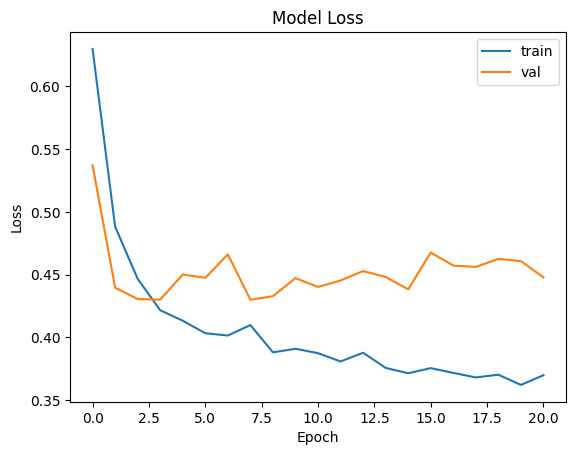

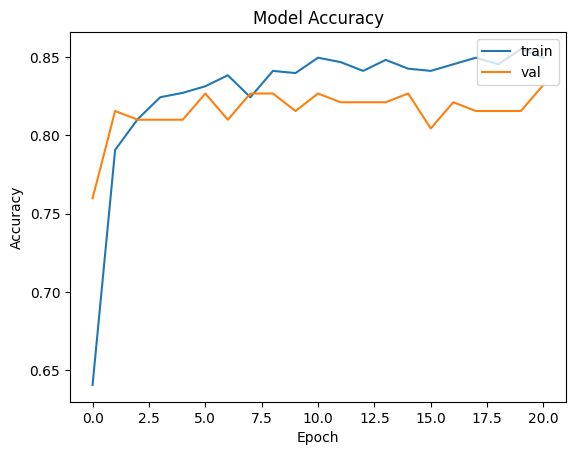

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['train', 'val'], loc='upper right')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['train', 'val'], loc='upper right')
plt.show()

In [18]:
test_df = pd.read_csv('test.csv')
test_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
test_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,8.0500,S
414,1,female,39.0,0,0,108.9000,C
415,3,male,38.5,0,0,7.2500,S
416,3,male,NaN,0,0,8.0500,S


In [19]:
test_prepared = full_pipeline.transform(test_df)
test_prepared.shape

(418, 12)

In [20]:
preds = model.predict(test_prepared)
preds[:5]

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([[0.09097641],
       [0.34422684],
       [0.04715096],
       [0.13352673],
       [0.3200637 ]], dtype=float32)

In [21]:
submission = pd.read_csv('gender_submission.csv')
submission['Survived'] = [0 if pred < 0.5 else 1 for pred in preds]
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [22]:
from IPython.display import FileLink


submission.to_csv('submission.csv',index=False)
FileLink(r'submission.csv')

/content/submission.csv